In [73]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [74]:

data = pd.read_csv("../data/processed_data2.csv")
data

,Distance (km),Estimated Duration (min),Weather Condition,Rainfall Intensity,Traffic Level,Temperature Level,Holiday,Day Type,Number of Stops Added,Fare (Target),...,Drop Area Type_Residential,Time Slot_Evening Rush,Time Slot_Late Night,Time Slot_Midday,Time Slot_Morning,Time Slot_Morning Rush,Time Slot_Night,Busy Day_Major Event,Busy Day_Normal,Busy Day_Public Holiday
0,150.44,429.9,0,0,1,4,0,0,0.0,2178,...,False,False,False,True,False,False,False,False,True,False
1,380.34,497.3,0,0,3,1,1,0,0.0,5679,...,False,False,True,False,False,False,False,False,False,True
2,293.07,769.7,1,0,1,2,1,0,4.0,4182,...,False,False,False,False,False,False,True,False,True,False
3,239.86,306.9,3,1,3,1,1,0,0.0,6811,...,False,False,False,True,False,False,False,False,True,False
4,63.25,123.6,0,0,0,1,0,0,0.0,943,...,True,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5787,328.05,1216.2,1,0,2,2,0,0,1.0,6172,...,False,True,False,False,False,False,False,False,True,False
5788,399.74,685.5,5,3,1,2,0,0,2.0,4299,...,True,False,True,False,False,False,False,False,True,False
5789,85.36,73.2,0,0,0,2,1,0,3.0,1150,...,False,False,False,False,False,True,False,False,True,False
5790,106.80,301.4,3,1,1,0,0,0,2.0,3299,...,False,False,False,False,True,False,False,False,True,False


In [75]:

data = data.drop(columns=[
    'Estimated Duration (min)',
    'Weather Condition' 
])

In [76]:
data.sort_values(
    by='Distance (km)',
    ascending=False
).head(50)

,Distance (km),Rainfall Intensity,Traffic Level,Temperature Level,Holiday,Day Type,Number of Stops Added,Fare (Target),Vehicle Type_Bike,Vehicle Type_Black,...,Drop Area Type_Residential,Time Slot_Evening Rush,Time Slot_Late Night,Time Slot_Midday,Time Slot_Morning,Time Slot_Morning Rush,Time Slot_Night,Busy Day_Major Event,Busy Day_Normal,Busy Day_Public Holiday
531,399.89,0,2,3,0,0,0.0,6217,False,False,...,True,False,False,True,False,False,False,False,True,False
3649,399.82,0,1,0,1,0,1.0,6792,False,False,...,False,False,False,True,False,False,False,False,False,True
1464,399.77,0,2,1,1,0,0.0,5086,False,False,...,False,False,False,False,False,False,True,False,True,False
5788,399.74,3,1,2,0,0,2.0,4299,False,False,...,True,False,True,False,False,False,False,False,True,False
3402,399.56,0,0,1,1,0,2.0,3928,True,False,...,True,False,True,False,False,False,False,True,False,False
5323,399.52,3,1,1,0,1,0.0,5444,False,False,...,False,False,True,False,False,False,False,False,True,False
1954,399.34,1,2,1,0,0,0.0,4644,False,False,...,False,False,False,False,True,False,False,False,True,False
1054,399.18,0,0,1,1,0,0.0,5432,False,False,...,False,True,False,False,False,False,False,False,True,False
2529,399.13,0,2,1,0,1,1.0,3471,True,False,...,False,False,False,False,False,False,True,False,True,False
4256,399.10,0,0,2,0,0,1.0,3687,True,False,...,False,False,True,False,False,False,False,True,False,False


In [77]:
data.dtypes

Distance (km)                       float64
Rainfall Intensity                    int64
Traffic Level                         int64
Temperature Level                     int64
Holiday                               int64
Day Type                              int64
Number of Stops Added               float64
Fare (Target)                         int64
Vehicle Type_Bike                      bool
Vehicle Type_Black                     bool
Vehicle Type_Comfort                   bool
Vehicle Type_Go                        bool
Vehicle Type_Mini                      bool
Vehicle Type_Pool                      bool
Vehicle Type_Premium                   bool
Vehicle Type_SUV                       bool
Vehicle Type_Sedan                     bool
Vehicle Type_XL                        bool
Road Type_Expressway                   bool
Road Type_Highway                      bool
Road Type_Rural Road                   bool
Pickup Area Type_Bus Stand             bool
Pickup Area Type_College        

In [79]:
X = data.drop(columns=['Fare (Target)'])
y = data['Fare (Target)']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4633, 47)
X_test: (1159, 47)
y_train: (4633,)
y_test: (1159,)


In [80]:

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](47,)","[ 12.38, 102.3 , 49.44,..., 152.23,-154.27, -13.85]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](47,)","['Distance (km)','Rainfall Intensity','Traffic Level',..., 'Busy Day_Major Event','Busy Day_Normal','Busy Day_Public Holiday']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-167.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,47
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(47)


In [81]:
y_pred = model.predict(X_test)
y_pred

array([2435.36845778, 4086.13751933, 2576.93778562, ..., 3775.94351639,
        489.2041286 , 1417.42545894], shape=(1159,))

In [82]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate residuals
residuals = y_test - y_pred

# Create dataframe
error_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Absolute Error': abs(residuals)
})

# Show top 10 largest errors
error_df = error_df.sort_values(by='Absolute Error', ascending=False)

print(error_df.head(10))


      Actual    Predicted  Absolute Error
925     1216  4257.724060     3041.724060
4801    1178  4037.095221     2859.095221
422     1544  4187.440193     2643.440193
5074   10836  8455.544548     2380.455452
2927    9414  7071.935613     2342.064387
1220    9776  7517.525317     2258.474683
2098   10246  8014.054740     2231.945260
5302    9600  7428.412013     2171.587987
4585    9424  7287.560796     2136.439204
3872    2789  4835.750573     2046.750573


In [83]:
y_pred = model.predict(X_test)

error_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Error": abs(y_test - y_pred)
})

In [33]:
error_df[error_df["Error"] > 2000].shape[0]

25

In [84]:
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [85]:
y_pred = model.predict(X_test)

error_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Error": abs(y_test - y_pred)
})
 

In [42]:
high_error_idx = error_df.sort_values(
    by="Error",
    ascending=False
).head(20).index
 

In [43]:
X_test.loc[high_error_idx]

,Distance (km),Rainfall Intensity,Traffic Level,Temperature Level,Holiday,Day Type,Number of Stops Added,Vehicle Type_Bike,Vehicle Type_Black,Vehicle Type_Comfort,...,Drop Area Type_Residential,Time Slot_Evening Rush,Time Slot_Late Night,Time Slot_Midday,Time Slot_Morning,Time Slot_Morning Rush,Time Slot_Night,Busy Day_Major Event,Busy Day_Normal,Busy Day_Public Holiday
109,233.09,3,1,0,1,0,0.0,False,True,False,...,True,False,False,False,False,False,False,False,False,True
1040,151.74,2,2,1,0,1,1.0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
437,137.38,0,3,0,1,1,3.0,False,True,False,...,False,False,False,False,False,False,True,False,False,True
494,280.34,2,3,1,0,0,0.0,False,False,False,...,False,False,True,False,False,False,False,False,True,False
1085,13.25,0,0,1,1,1,0.0,False,False,False,...,True,False,False,True,False,False,False,False,False,False
543,340.85,0,0,1,1,0,0.0,True,False,False,...,True,False,False,False,False,False,False,False,True,False
505,168.65,2,1,1,1,1,1.0,False,False,False,...,True,False,False,False,False,False,True,False,True,False
993,149.52,3,3,2,1,1,0.0,False,False,False,...,False,True,False,False,False,False,False,False,True,False
344,282.64,0,1,2,0,0,3.0,False,False,False,...,False,False,False,False,True,False,False,False,True,False
697,281.72,0,2,1,0,0,1.0,True,False,False,...,False,False,True,False,False,False,False,False,True,False


In [44]:
high_error_rows = pd.concat(
    [X_test.loc[high_error_idx],
     error_df.loc[high_error_idx]],
    axis=1
)

high_error_rows

,Distance (km),Rainfall Intensity,Traffic Level,Temperature Level,Holiday,Day Type,Number of Stops Added,Vehicle Type_Bike,Vehicle Type_Black,Vehicle Type_Comfort,...,Time Slot_Midday,Time Slot_Morning,Time Slot_Morning Rush,Time Slot_Night,Busy Day_Major Event,Busy Day_Normal,Busy Day_Public Holiday,Actual,Predicted,Error
109,233.09,3,1,0,1,0,0.0,False,True,False,...,False,False,False,False,False,False,True,24444,7640.556318,16803.443682
1040,151.74,2,2,1,0,1,1.0,False,True,False,...,False,False,False,False,True,False,False,12538,6165.056568,6372.943432
437,137.38,0,3,0,1,1,3.0,False,True,False,...,False,False,False,True,False,False,True,9908,4505.365081,5402.634919
494,280.34,2,3,1,0,0,0.0,False,False,False,...,False,False,False,False,False,True,False,12867,7887.827303,4979.172697
1085,13.25,0,0,1,1,1,0.0,False,False,False,...,True,False,False,False,False,False,False,4616,143.445670,4472.554330
543,340.85,0,0,1,1,0,0.0,True,False,False,...,False,False,False,False,False,True,False,3157,7301.009369,4144.009369
505,168.65,2,1,1,1,1,1.0,False,False,False,...,False,False,False,True,False,True,False,9556,5450.272943,4105.727057
993,149.52,3,3,2,1,1,0.0,False,False,False,...,False,False,False,False,False,True,False,9151,5602.112207,3548.887793
344,282.64,0,1,2,0,0,3.0,False,False,False,...,False,True,False,False,False,True,False,3261,6643.464288,3382.464288
697,281.72,0,2,1,0,0,1.0,True,False,False,...,False,False,False,False,False,True,False,2854,6220.673271,3366.673271


In [45]:
high_error_rows.to_csv("high_error_rows.csv", index=False)


In [46]:
print(data['Distance (km)'].describe())

print(
    data['Distance (km)'].quantile(
        [0.95, 0.99, 0.995]
    )
)

count    5792.000000
mean       29.632246
std        51.050134
min         1.000000
25%         7.260000
50%        13.250000
75%        22.080000
max       385.940000
Name: Distance (km), dtype: float64
0.950    161.8870
0.990    246.6088
0.995    284.9659
Name: Distance (km), dtype: float64


In [ ]:
data.sort_values(
    by='Distance (km)',
    ascending=False
).head(50)

In [54]:
data = data[data['Distance (km)'] <= 200]
data

,Distance (km),Rainfall Intensity,Traffic Level,Temperature Level,Holiday,Day Type,Number of Stops Added,Fare (Target),Vehicle Type_Bike,Vehicle Type_Black,...,Drop Area Type_Residential,Time Slot_Evening Rush,Time Slot_Late Night,Time Slot_Midday,Time Slot_Morning,Time Slot_Morning Rush,Time Slot_Night,Busy Day_Major Event,Busy Day_Normal,Busy Day_Public Holiday
0,20.81,0,1,4,0,0,0.0,749,False,False,...,False,False,False,True,False,False,False,False,True,False
1,9.58,0,3,1,1,0,0.0,811,False,False,...,False,False,True,False,False,False,False,False,False,True
2,5.36,0,1,2,1,0,4.0,30,False,False,...,False,False,False,False,False,False,True,False,True,False
3,5.00,1,3,1,1,0,0.0,1243,False,True,...,False,False,False,True,False,False,False,False,True,False
4,18.14,0,0,1,0,0,0.0,30,False,False,...,True,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5787,11.01,0,2,2,0,0,1.0,1104,False,False,...,False,True,False,False,False,False,False,False,True,False
5788,7.53,3,1,2,0,0,2.0,897,False,False,...,True,False,True,False,False,False,False,False,True,False
5789,5.60,0,0,2,1,0,3.0,30,True,False,...,False,False,False,False,False,True,False,False,True,False
5790,4.78,1,1,0,0,0,2.0,1320,False,True,...,False,False,False,False,True,False,False,False,True,False


In [86]:


print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred)**0.5)
print("R² Score:", r2_score(y_test, y_pred))

MAE : 349.5257785341518
MSE : 256924.19311092366
RMSE: 506.87690133889873
R² Score: 0.9092569283084572


In [93]:
from sklearn.metrics import r2_score

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))

Train R2: 0.9157888988707213
Test R2: 0.9092569283084572


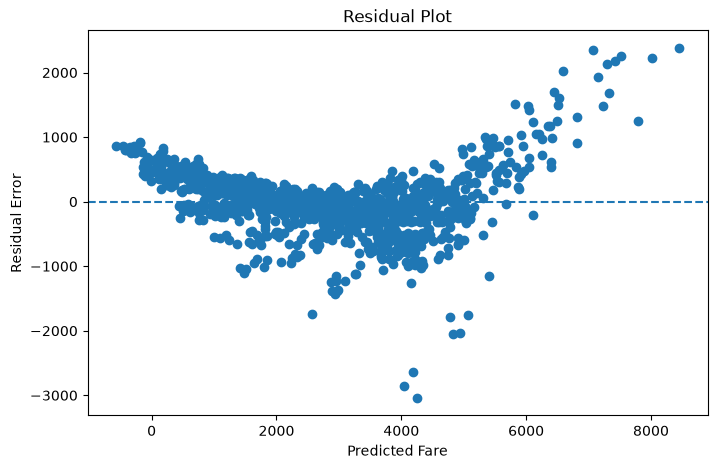

In [88]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Fare")
plt.ylabel("Residual Error")
plt.title("Residual Plot")

plt.show()

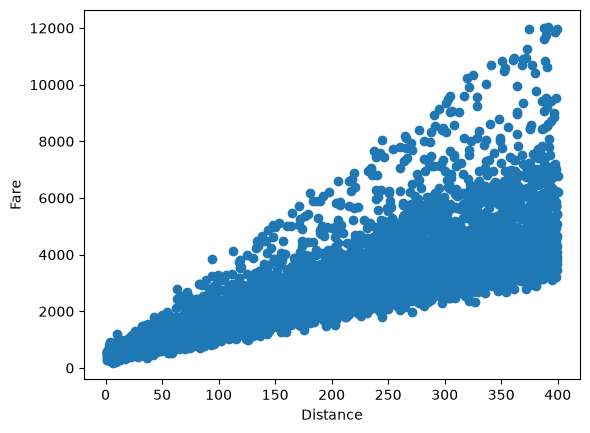

In [89]:
import matplotlib.pyplot as plt

plt.scatter(
    data['Distance (km)'],
    data['Fare (Target)']
)

plt.xlabel("Distance")
plt.ylabel("Fare")
plt.show()

In [91]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [92]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", mean_squared_error(y_test, rf_pred)**0.5)
print("R2:", r2_score(y_test, rf_pred))

MAE: 154.93366264020707
RMSE: 204.2395213399136
R2: 0.9852671067223373


In [98]:
import pandas as pd

# Create a row with all features initialized as 0
bike_prediction = pd.DataFrame(
    0,
    index=[0],
    columns=X_train.columns
)

# Numeric features
bike_prediction['Distance (km)'] = 15
bike_prediction['Estimated Duration (min)'] = 30

# Normal conditions
bike_prediction['Weather Condition'] = 0        # Clear
bike_prediction['Rainfall Intensity'] = 0       # No Rain
bike_prediction['Traffic Level'] = 0            # Low
bike_prediction['Temperature Level'] = 1        # Pleasant
bike_prediction['Holiday'] = 0                  # No Holiday
bike_prediction['Day Type'] = 0                 # Weekday
bike_prediction['Number of Stops Added'] = 0

# Normal categorical values
bike_prediction['Pickup Area Type_Residential'] = 1
bike_prediction['Drop Area Type_Residential'] = 1
bike_prediction['Time Slot_Midday'] = 1
bike_prediction['Busy Day_Normal'] = 1

# Vehicle type = Bike
bike_prediction['Vehicle Type_Bike'] = 1

# Prediction
predicted_bike_fare = model.predict(bike_prediction)[0]

print(f"Predicted Bike Fare for 15 km: ₹{predicted_bike_fare:.2f}")

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Estimated Duration (min)
- Weather Condition
